In [1]:
import os
import re
import networkx as nx

data_path = os.path.expanduser("~/CN/A2_synthetic_networks")

networks = {}

files = sorted([f for f in os.listdir(data_path) if f.endswith('.net')])

for fname in files:
    match = re.search(r'prr_([\d.]+)_prs', fname)
    if match:
        prr = float(match.group(1))
        fpath = os.path.join(data_path, fname)
        G = nx.read_pajek(fpath)
        G = nx.Graph(G)
        networks[prr] = G

print(f"Redes cargadas: {len(networks)}")
print(f"\nEjemplo — prr=0.04:")
G_ex = networks[0.04]
print(f"  Nodos: {G_ex.number_of_nodes()}")
print(f"  Aristas: {G_ex.number_of_edges()}")
print(f"  Nodos ejemplo: {list(G_ex.nodes())[:5]}")

Redes cargadas: 51

Ejemplo — prr=0.04:
  Nodos: 300
  Aristas: 1102
  Nodos ejemplo: ['1', '2', '3', '4', '5']


In [2]:
ground_truth = {}
for i in range(1, 301):
    node = str(i)
    community = (i - 1) // 60
    ground_truth[node] = community

print("Ground truth (primeros y últimos de cada bloque):")
checkpoints = [1, 60, 61, 120, 121, 180, 181, 240, 241, 300]
for i in checkpoints:
    print(f"  Nodo {i:>3} → bloque {ground_truth[str(i)]}")

Ground truth (primeros y últimos de cada bloque):
  Nodo   1 → bloque 0
  Nodo  60 → bloque 0
  Nodo  61 → bloque 1
  Nodo 120 → bloque 1
  Nodo 121 → bloque 2
  Nodo 180 → bloque 2
  Nodo 181 → bloque 3
  Nodo 240 → bloque 3
  Nodo 241 → bloque 4
  Nodo 300 → bloque 4


In [3]:
import igraph as ig
import leidenalg
import numpy as np

def nx_to_igraph(G_nx):
    nodes = list(G_nx.nodes())
    node_index = {n: i for i, n in enumerate(nodes)}
    edges = [(node_index[u], node_index[v]) for u, v in G_nx.edges()]
    G_ig = ig.Graph(n=len(nodes), edges=edges)
    G_ig.vs["name"] = nodes
    return G_ig, nodes

def partition_to_dict(membership, nodes):
    return {nodes[i]: membership[i] for i in range(len(nodes))}

results = {
    'infomap': {},
    'louvain': {},
    'leiden':  {}
}

prr_values = sorted(networks.keys())

print("Procesando redes...")
for prr in prr_values:
    G_nx = networks[prr]
    G_ig, nodes = nx_to_igraph(G_nx)

    im = G_ig.community_infomap()
    results['infomap'][prr] = {
        'n_communities': len(im),
        'modularity':    G_ig.modularity(im.membership),
        'partition':     partition_to_dict(im.membership, nodes)
    }

    lv = G_ig.community_multilevel()
    results['louvain'][prr] = {
        'n_communities': len(lv),
        'modularity':    G_ig.modularity(lv.membership),
        'partition':     partition_to_dict(lv.membership, nodes)
    }

    ld = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition)
    results['leiden'][prr] = {
        'n_communities': len(ld),
        'modularity':    G_ig.modularity(ld.membership),
        'partition':     partition_to_dict(ld.membership, nodes)
    }

print(f"\nprr=0.16:")
for algo in results:
    r = results[algo][0.16]
    print(f"  {algo:<10} comunidades={r['n_communities']}  Q={r['modularity']:.4f}")

Procesando redes...

prr=0.16:
  infomap    comunidades=5  Q=0.4588
  louvain    comunidades=5  Q=0.4588
  leiden     comunidades=5  Q=0.4588


In [4]:
from sklearn.metrics import normalized_mutual_info_score
from itertools import combinations
import numpy as np

def jaccard_partition(part1, part2):
    nodes = list(part1.keys())
    a = b = c = 0
    for u, v in combinations(nodes, 2):
        same1 = part1[u] == part1[v]
        same2 = part2[u] == part2[v]
        if same1 and same2:
            a += 1
        elif same1 and not same2:
            b += 1
        elif not same1 and same2:
            c += 1
    return a / (a + b + c) if (a + b + c) > 0 else 0.0

def compute_metrics(partition, ground_truth):
    nodes = list(ground_truth.keys())
    
    labels_true = [ground_truth[n] for n in nodes]
    labels_pred = [partition[n] for n in nodes]
    
    nmi = normalized_mutual_info_score(labels_true, labels_pred, 
                                        average_method='arithmetic')
    nvi = 1 - nmi
    jac = jaccard_partition(partition, ground_truth)
    
    return {'jaccard': jac, 'nmi': nmi, 'nvi': nvi}


metrics = {algo: {} for algo in results}

for algo in results:
    for prr in prr_values:
        partition = results[algo][prr]['partition']
        metrics[algo][prr] = compute_metrics(partition, ground_truth)
    print(f"  {algo} listo")

print(f"\nprr=0.16:")
for algo in metrics:
    m = metrics[algo][0.16]
    print(f"  {algo:<10} Jaccard={m['jaccard']:.4f}  NMI={m['nmi']:.4f}  NVI={m['nvi']:.4f}")

  infomap listo
  louvain listo
  leiden listo

prr=0.16:
  infomap    Jaccard=1.0000  NMI=1.0000  NVI=0.0000
  louvain    Jaccard=1.0000  NMI=1.0000  NVI=0.0000
  leiden     Jaccard=1.0000  NMI=1.0000  NVI=0.0000


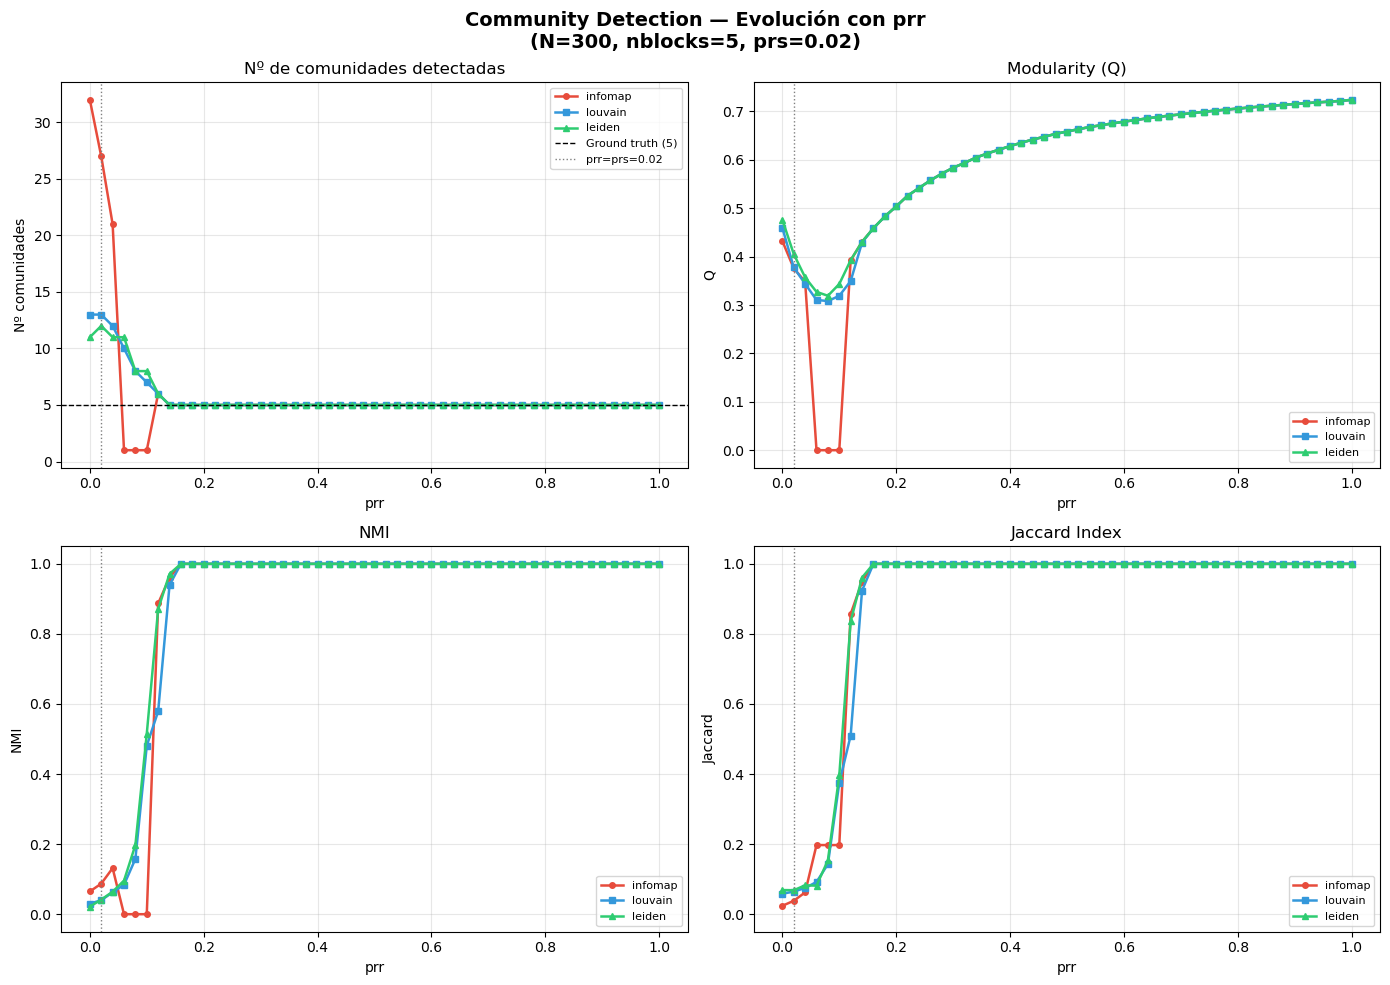

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

algos   = ['infomap', 'louvain', 'leiden']
colors  = {'infomap': '#e74c3c', 'louvain': '#3498db', 'leiden': '#2ecc71'}
markers = {'infomap': 'o',       'louvain': 's',        'leiden': '^'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Community Detection — Evolución con prr\n(N=300, nblocks=5, prs=0.02)',
             fontsize=14, fontweight='bold')

prr_arr = np.array(prr_values)

ax = axes[0, 0]
for algo in algos:
    y = [results[algo][p]['n_communities'] for p in prr_values]
    ax.plot(prr_arr, y, color=colors[algo], marker=markers[algo],
            markersize=4, label=algo, linewidth=1.8)
ax.axhline(5, color='black', linestyle='--', linewidth=1, label='Ground truth (5)')
ax.axvline(0.02, color='gray', linestyle=':', linewidth=1, label='prr=prs=0.02')
ax.set_title('Nº de comunidades detectadas')
ax.set_xlabel('prr'); ax.set_ylabel('Nº comunidades')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0, 1]
for algo in algos:
    y = [results[algo][p]['modularity'] for p in prr_values]
    ax.plot(prr_arr, y, color=colors[algo], marker=markers[algo],
            markersize=4, label=algo, linewidth=1.8)
ax.axvline(0.02, color='gray', linestyle=':', linewidth=1)
ax.set_title('Modularity (Q)')
ax.set_xlabel('prr'); ax.set_ylabel('Q')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 0]
for algo in algos:
    y = [metrics[algo][p]['nmi'] for p in prr_values]
    ax.plot(prr_arr, y, color=colors[algo], marker=markers[algo],
            markersize=4, label=algo, linewidth=1.8)
ax.axvline(0.02, color='gray', linestyle=':', linewidth=1)
ax.set_title('NMI')
ax.set_xlabel('prr'); ax.set_ylabel('NMI')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
for algo in algos:
    y = [metrics[algo][p]['jaccard'] for p in prr_values]
    ax.plot(prr_arr, y, color=colors[algo], marker=markers[algo],
            markersize=4, label=algo, linewidth=1.8)
ax.axvline(0.02, color='gray', linestyle=':', linewidth=1)
ax.set_title('Jaccard Index')
ax.set_xlabel('prr'); ax.set_ylabel('Jaccard')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.expanduser('~/CN/A2_evolution_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

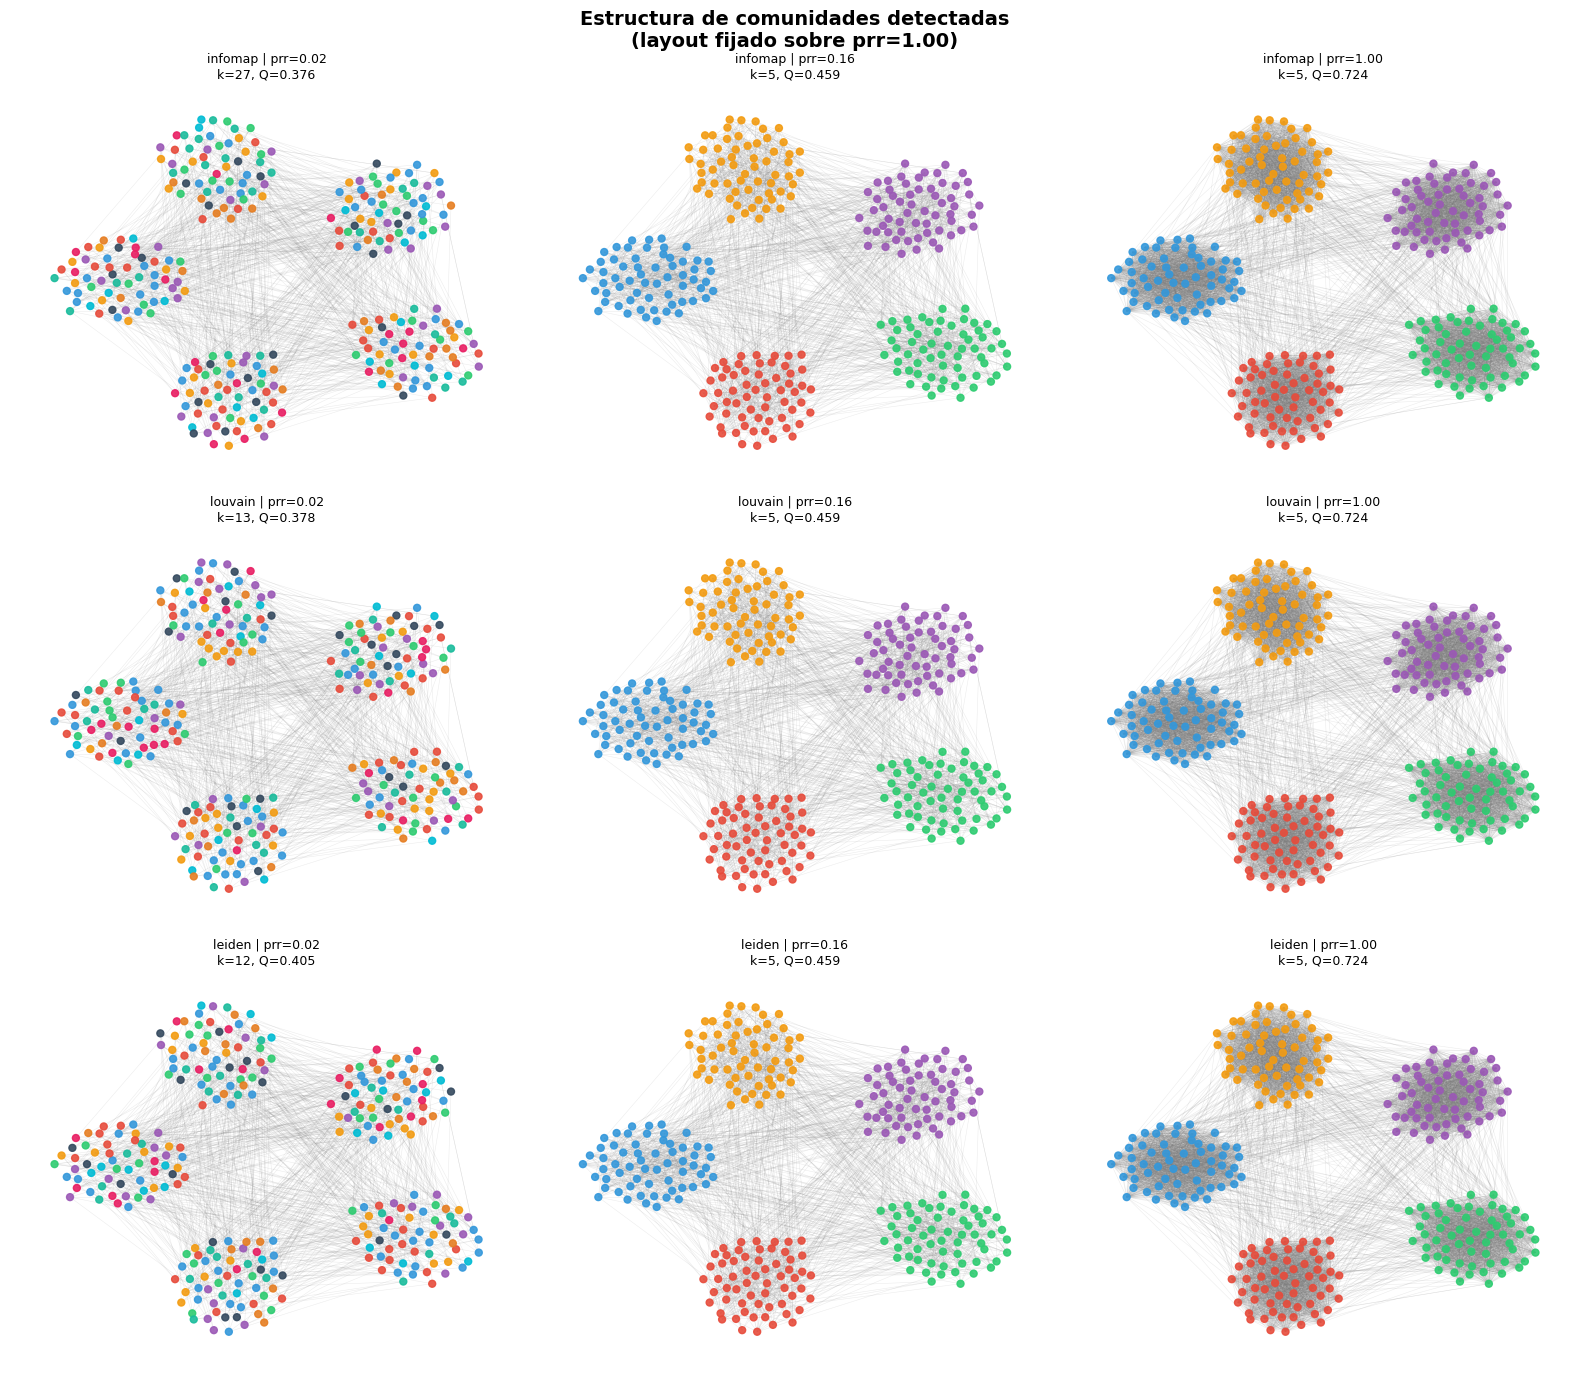

Visualización guardada


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


G_layout = networks[1.00]
pos = nx.spring_layout(G_layout, seed=42, k=0.3, iterations=100)


PALETTE = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6',
           '#1abc9c', '#e67e22', '#34495e', '#e91e63', '#00bcd4']

def get_node_colors(partition, nodes, max_communities=None):
    from collections import Counter
    counts = Counter(partition.values())
    remap = {old: new for new, (old, _) in enumerate(counts.most_common())}
    return [PALETTE[remap[partition[n]] % len(PALETTE)] for n in nodes]

prr_plot  = [0.02, 0.16, 1.00]
algo_list = ['infomap', 'louvain', 'leiden']
nodes_ordered = list(networks[1.00].nodes())

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Estructura de comunidades detectadas\n(layout fijado sobre prr=1.00)',
             fontsize=14, fontweight='bold')

for row, algo in enumerate(algo_list):
    for col, prr in enumerate(prr_plot):
        ax = axes[row, col]
        G  = networks[prr]
        
        partition  = results[algo][prr]['partition']
        node_colors = get_node_colors(partition, nodes_ordered)
        n_comm = results[algo][prr]['n_communities']
        Q      = results[algo][prr]['modularity']
        
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15,
                               edge_color='gray', width=0.4)
        nx.draw_networkx_nodes(G, pos, ax=ax,
                               node_color=node_colors,
                               node_size=25, alpha=0.9)
        
        ax.set_title(f'{algo} | prr={prr:.2f}\nk={n_comm}, Q={Q:.3f}',
                     fontsize=9)
        ax.axis('off')

for row, algo in enumerate(algo_list):
    axes[row, 0].set_ylabel(algo, fontsize=11, fontweight='bold', labelpad=10)
    axes[row, 0].yaxis.label.set_visible(True)

plt.tight_layout()
plt.savefig(os.path.expanduser('~/CN/A2_network_visualization.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualización guardada")

In [8]:
import pandas as pd

rows = []
for algo in algo_list:
    for prr in prr_values:
        r = results[algo][prr]
        m = metrics[algo][prr]
        rows.append({
            'algoritmo':     algo,
            'prr':           prr,
            'n_comunidades': r['n_communities'],
            'modularity_Q':  round(r['modularity'], 4),
            'NMI':           round(m['nmi'], 4),
            'NVI':           round(m['nvi'], 4),
            'Jaccard':       round(m['jaccard'], 4),
        })

df = pd.DataFrame(rows)

csv_path = os.path.expanduser('~/CN/A2_results_table.csv')
df.to_csv(csv_path, index=False)
print(f"Tabla guardada en {csv_path}")

prr_key = [0.00, 0.02, 0.04, 0.08, 0.10, 0.12, 0.14, 0.16, 0.50, 1.00]
print("\n── Tabla resumen ──")
mask = df['prr'].isin(prr_key)
print(df[mask].to_string(index=False))

Tabla guardada en /home/jovyan/CN/A2_results_table.csv

── Tabla resumen ──
algoritmo  prr  n_comunidades  modularity_Q    NMI    NVI  Jaccard
  infomap 0.00             32        0.4323 0.0649 0.9351   0.0240
  infomap 0.02             27        0.3759 0.0872 0.9128   0.0382
  infomap 0.04             21        0.3483 0.1315 0.8685   0.0622
  infomap 0.08              1        0.0000 0.0000 1.0000   0.1973
  infomap 0.10              1        0.0000 0.0000 1.0000   0.1973
  infomap 0.12              6        0.3925 0.8872 0.1128   0.8570
  infomap 0.14              5        0.4307 0.9608 0.0392   0.9486
  infomap 0.16              5        0.4588 1.0000 0.0000   1.0000
  infomap 0.50              5        0.6586 1.0000 0.0000   1.0000
  infomap 1.00              5        0.7240 1.0000 0.0000   1.0000
  louvain 0.00             13        0.4595 0.0303 0.9697   0.0583
  louvain 0.02             13        0.3777 0.0398 0.9602   0.0646
  louvain 0.04             12        0.3438 0.0626 0.